#***Librerias***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
from sklearn.naive_bayes import GaussianNB #importa el algoritmo
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import *
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

#**Dataset - Drive**

In [2]:
from google.colab import drive
drive.mount('/content/Mydrive')

file_path = '/content/Mydrive/MyDrive/PROYECTO-IA/ObesityDataSet.csv'

df = pd.read_csv(file_path)


Mounted at /content/Mydrive


##**Filtrado**

In [3]:
#Detectar nulos en los registros
nulos_por_columna = pd.isnull(df).sum()


#**Conversión categoricas a numericas**

In [4]:
#NOTA: Ten encuenta que solo se ejecuta una vez para visualizar, ya que si lo haces nuevamente ya las actegoricas son numericas

#   columnas categóricas
df=df.drop("SMOKE",axis=1)
categorical_cols = df.select_dtypes(include=['object']).columns
print("Columnas categóricas:", categorical_cols.tolist())

# Diccionario para guardar los mapeos
mapeos = {}

# Transformar cada columna categórica y guardar el mapeo
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].fillna('missing')  # para manejar nulos
    df[col] = le.fit_transform(df[col])
    mapeos[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# Mostrar los mapeos
print("\nMapeos de columnas categóricas:\n")
for col, mapping in mapeos.items():
    print(f"Columna: {col}")
    for categoria, valor in mapping.items():
        print(f"  {categoria}: {valor}")
    print("-" * 40)



Columnas categóricas: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

Mapeos de columnas categóricas:

Columna: Gender
  Female: 0
  Male: 1
----------------------------------------
Columna: family_history_with_overweight
  no: 0
  yes: 1
----------------------------------------
Columna: FAVC
  no: 0
  yes: 1
----------------------------------------
Columna: CAEC
  Always: 0
  Frequently: 1
  Sometimes: 2
  no: 3
----------------------------------------
Columna: SCC
  no: 0
  yes: 1
----------------------------------------
Columna: CALC
  Always: 0
  Frequently: 1
  Sometimes: 2
  no: 3
----------------------------------------
Columna: MTRANS
  Automobile: 0
  Bike: 1
  Motorbike: 2
  Public_Transportation: 3
  Walking: 4
----------------------------------------
Columna: NObeyesdad
  Insufficient_Weight: 0
  Normal_Weight: 1
  Obesity_Type_I: 2
  Obesity_Type_II: 3
  Obesity_Type_III: 4
  Overweight_Level_I: 5
  Overweight_Level_II: 

#**Decision Tree "Arbol de decisión"**

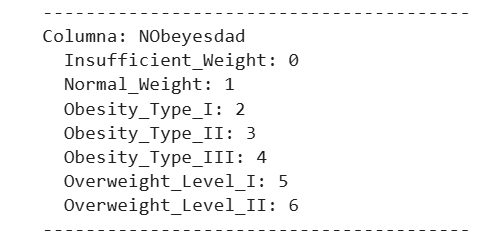

Se realiza la prueba del modelo con 80% train y 20% test.

In [5]:
X = df.values[:,:-1]
y = df.values[:,-1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40, shuffle=True,stratify=y
)


X_train_curva, X_test_curva, y_train_curva, y_test_curva = train_test_split(
    X_train, y_train, test_size=0.125, random_state=40, shuffle=False
)




In [6]:

est = DecisionTreeClassifier(max_depth=5)
est.fit(X_train,y_train)




dt_train_acc = accuracy_score(y_train, est.predict(X_train))
dt_test_acc = accuracy_score(y_test, est.predict(X_test))
print("Entrenamiento: ", dt_train_acc)
print("Test: ",dt_test_acc)
print("Reporte de metricas")
print(classification_report(y_test,est.predict(X_test)))

r=classification_report(y_test,est.predict(X_test),output_dict=True)
recall_df=r['macro avg']['recall']

s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True), scoring=make_scorer(accuracy_score))
print("accuracy %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))

print("PREDICCIÓN")
print(X_test[10])
print("Prediccion: ",est.predict([X_test[10]]),"Real: ",y_test[10])
print("Prediccion: ",est.predict([X_test[56]]),"Real: ",y_test[56])
print("Prediccion: ",est.predict([X_test[1]]),"Real: ",y_test[1])
print("Prediccion: ",est.predict([X_test[12]]),"Real: ",y_test[12])

Entrenamiento:  0.8311611374407583
Test:  0.8463356973995272
Reporte de metricas
              precision    recall  f1-score   support

         0.0       0.98      0.93      0.95        54
         1.0       0.91      0.69      0.78        58
         2.0       0.76      0.96      0.85        70
         3.0       0.97      0.93      0.95        60
         4.0       1.00      0.98      0.99        65
         5.0       0.71      0.67      0.69        58
         6.0       0.67      0.72      0.69        58

    accuracy                           0.85       423
   macro avg       0.86      0.84      0.84       423
weighted avg       0.86      0.85      0.85       423

accuracy 0.815 (+/- 0.02474)
PREDICCIÓN
[ 1.   28.    1.81 87.29  0.    1.    3.    3.    2.    1.21  0.    2.
  0.    3.    0.  ]
Prediccion:  [6.] Real:  5.0
Prediccion:  [4.] Real:  4.0
Prediccion:  [6.] Real:  6.0
Prediccion:  [2.] Real:  2.0


Matriz de confusión

<Figure size 1000x800 with 0 Axes>

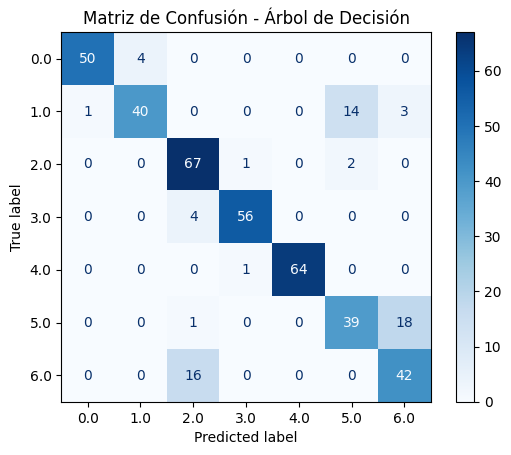

In [7]:

abreviaturas = {
    0: 'Bajo Peso',
    1: 'Normal',
    2: 'Obesidad I',
    3: 'Obesidad II',
    4: 'Obesidad III',
    5: 'Sobrepeso I',
    6: 'Sobrepeso II'
}

# Clases originales del modelo
clases_originales = est.classes_

# Calcular la matriz de confusión usando las clases originales
cm = confusion_matrix(y_test, est.predict(X_test), labels=clases_originales)

# Convertir los nombres a abreviaturas solo para mostrar en la gráfica
#labels_abreviadas = [abreviaturas[c] for c in clases_originales]

# Graficar
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases_originales)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

Grafico

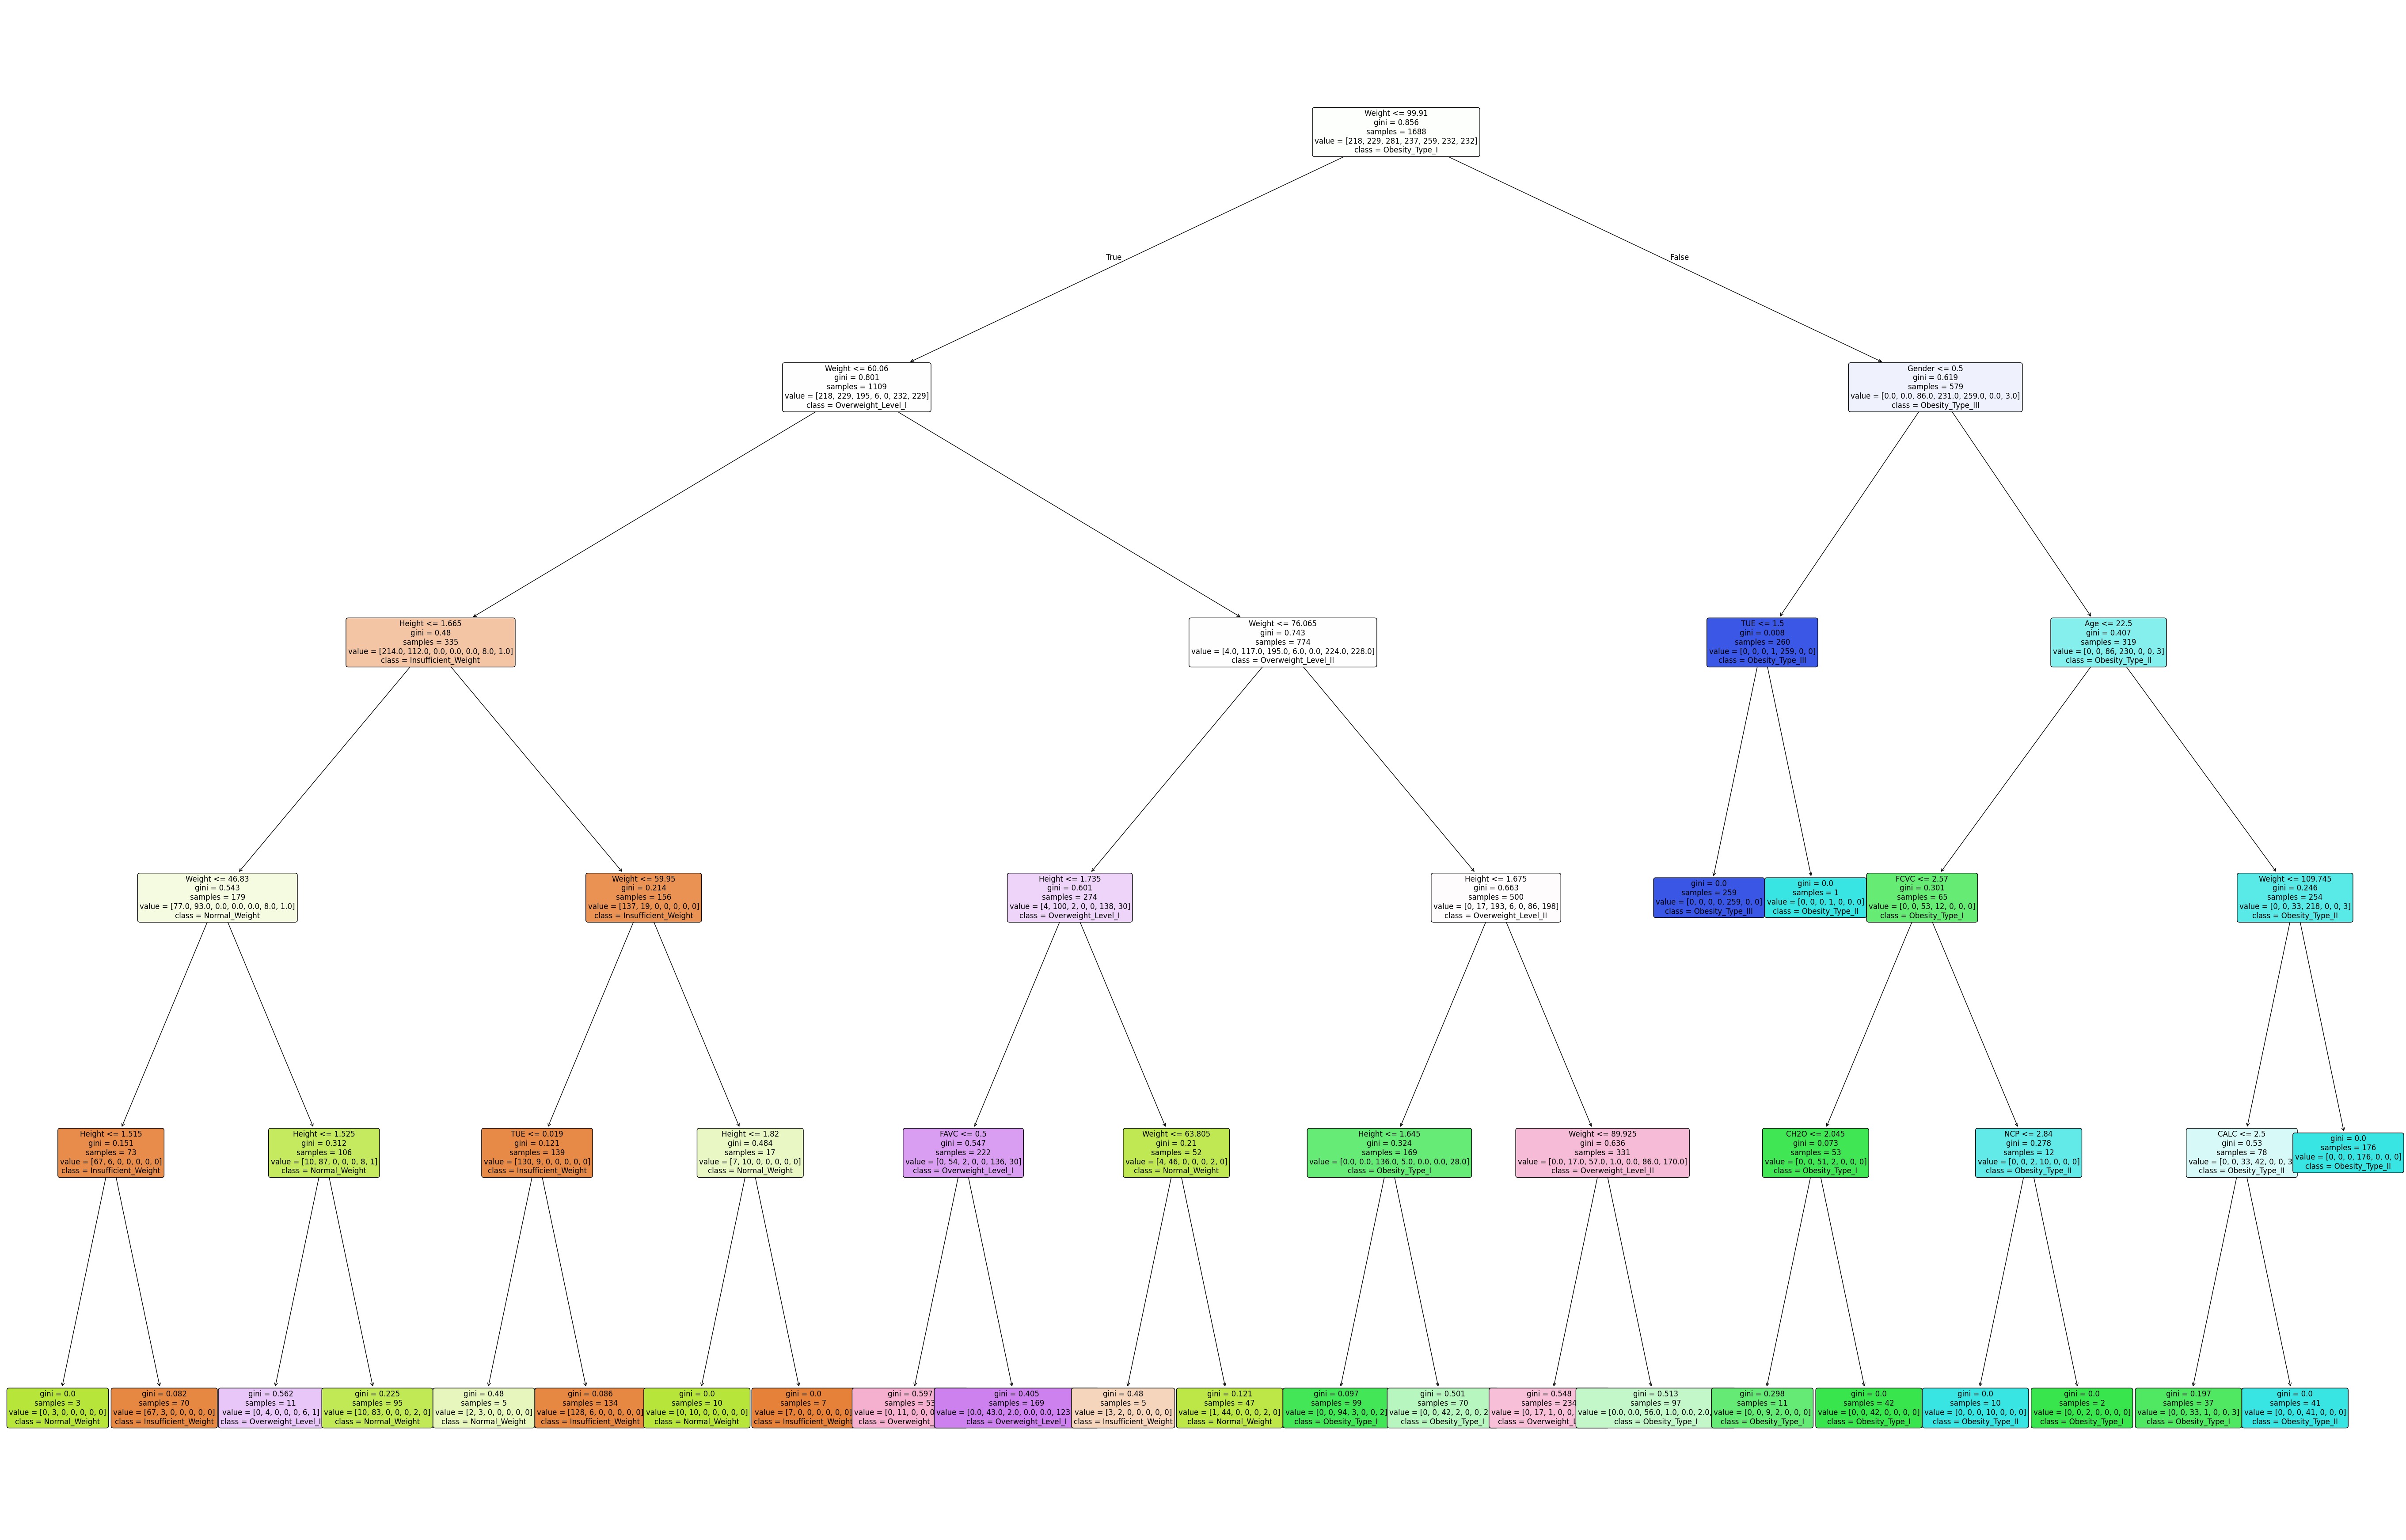

In [ ]:

class_names = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
    "Overweight_Level_I",
    "Overweight_Level_II"
]

# Dibujar árbol
plt.figure(figsize=(70,45))


plot_tree(
    est,
    feature_names=df.columns[:-1],  # nombres de las columnas
    #class_names=[str(c) for c in np.unique(y)],  # clases como texto
    class_names=class_names,
    filled=True,  # colorea los nodos según la clase
    rounded=True, # bordes redondeados
    fontsize=12,
)
plt.show()

Curva de aprendizaje

La curva de aprendizaje se realiza para ver si hay sobreajuste o subajuste con respecto al modelo, por ende, se realiza con diferentes tamaños de entrenamiento.

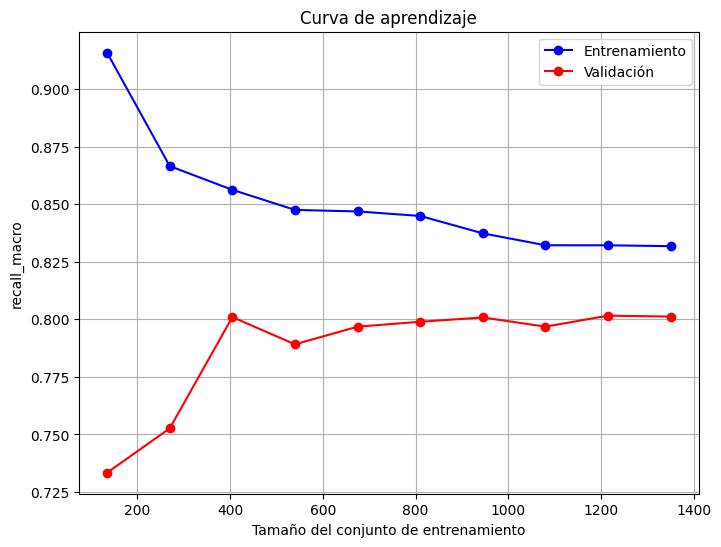

In [ ]:

train_sizes, train_scores, test_scores = learning_curve(
    est,
    X_train, y_train,             # datos
    cv=5,             # k-fold cross-validation
    scoring='recall_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),  # desde 10% hasta 100% del entrenamiento
    shuffle=True,
    random_state=40
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)


plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Entrenamiento')
plt.plot(train_sizes, test_mean, 'o-', color='red', label='Validación')
#plt.fill_between(train_sizes, train_mean - test_std, train_mean + test_std, alpha=0.2)
#plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)


plt.title('Curva de aprendizaje')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('recall_macro')
plt.legend()
plt.grid(True)
plt.show()



Sobreajuste (Alta Varianza): El modelo es demasiado complejo. Aprende muy bien el ruido del entrenamiento (azul muy alta), pero falla en datos nuevos (roja muy baja).

Subajuste (Alto Sesgo): El modelo es demasiado simple. No aprende las relaciones clave ni en entrenamiento ni en validación (ambas curvas son bajas).

Ideal: El modelo generaliza bien. Ambas curvas están cerca y con una precisión razonablemente alta.

Arbol visualizado

***Conclusión***

Para iniciar cada parametro tiene cierta influencia en el resultado que proporciona los modelos, en este caso se destaca la profundidad "max_depth", el cual entre mas profundo hay un sobreajuste (tiene a decir resultados por memoria(trampa) y no por prediccion).




CARACTERISTICAS MAS IMPORTANTES

                    Caracteristica  Importancia
3                           Weight     0.518995
0                           Gender     0.214122
2                           Height     0.149157
1                              Age     0.045250
13                            CALC     0.032188
5                             FAVC     0.020166
6                             FCVC     0.011723
12                             TUE     0.004698
7                              NCP     0.003155
9                             CH2O     0.000545
4   family_history_with_overweight     0.000000
10                             SCC     0.000000
8                             CAEC     0.000000
11                             FAF     0.000000
14                          MTRANS     0.000000


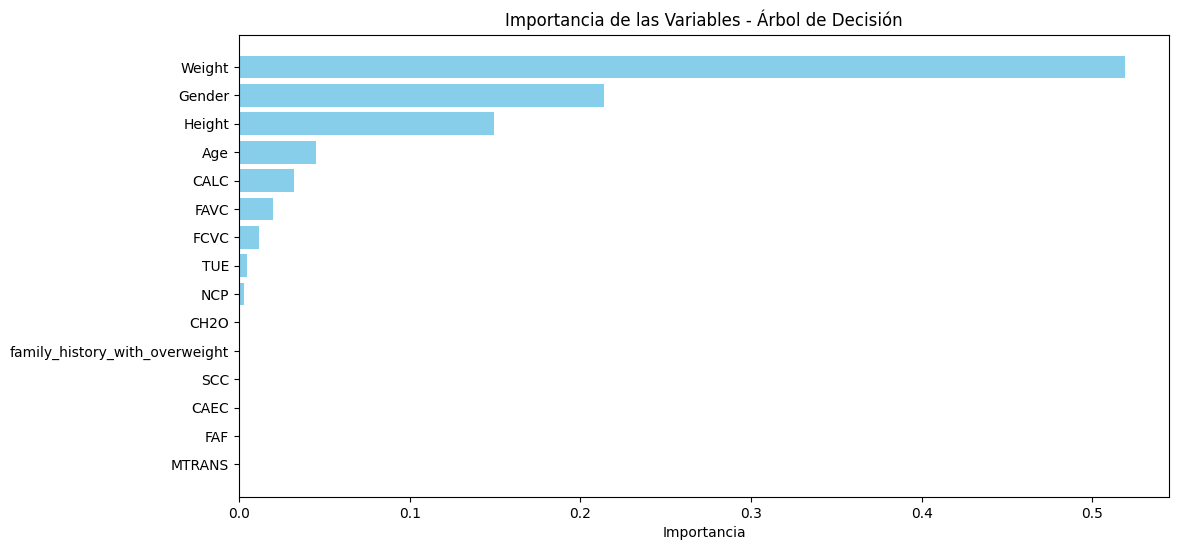

In [ ]:
# Crear un DataFrame para ordenar y visualizar
importancias = est.feature_importances_
feat_importances = pd.DataFrame({
    'Caracteristica': df.columns[:-1],
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print(feat_importances)

# Graficar todas las caracteirsticas
plt.figure(figsize=(12,6))
plt.barh(feat_importances['Caracteristica'], feat_importances['Importancia'], color='skyblue')
plt.gca().invert_yaxis()  # la más importante arriba
plt.xlabel('Importancia')
plt.title('Importancia de las Variables - Árbol de Decisión')
plt.show()



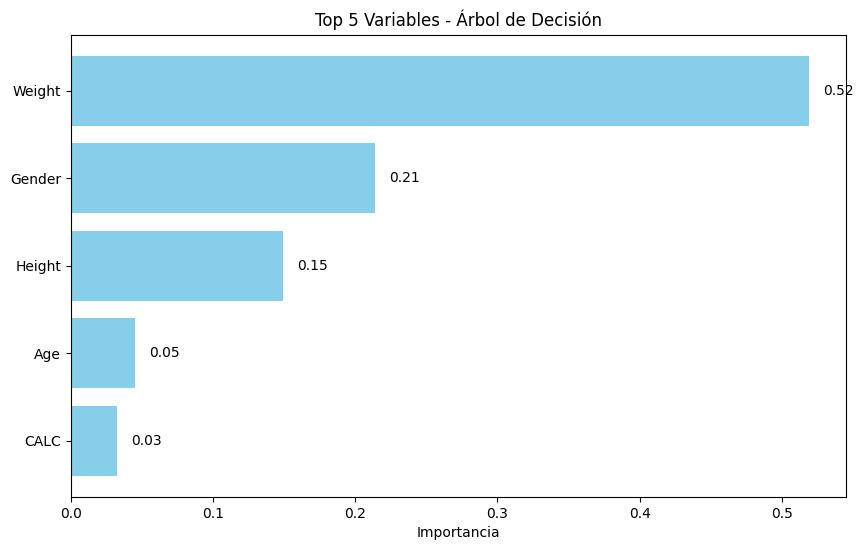

In [ ]:
#las 5 mas importantes

top_n = 5
top_feat = feat_importances.head(top_n)

plt.figure(figsize=(10,6))
bars = plt.barh(top_feat['Caracteristica'], top_feat['Importancia'], color='skyblue')
plt.gca().invert_yaxis()  # la más importante arriba
plt.xlabel('Importancia')
plt.title(f'Top {top_n} Variables - Árbol de Decisión')

# Mostrar los valores sobre cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center')

plt.show()


Entrenamiento con solo la mas importante

In [ ]:
# Seleccionar solo las columnas más importantes
X_train_top = X_train[:, [3, 0, 2, 1]]  # índices de Weight, Gender, Height, Age
X_test_top  = X_test[:, [3, 0, 2, 1]]

# Reentrenar árbol con menos variables
est_top = DecisionTreeClassifier(max_depth=4)
est_top.fit(X_train_top, y_train)

# Evaluar
print("Accuracy Test:", accuracy_score(y_test, est_top.predict(X_test_top)))


Accuracy Test: 0.7659574468085106


Probar con algoritmos el max_depth

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

profundidades = [2, 3, 4, 5, 6, 8, 10, 12, None]  # None = árbol sin límite
resultados = []

for d in profundidades:
    modelo = DecisionTreeClassifier(max_depth=d, random_state=40)
    score = cross_val_score(modelo, X_train, y_train, cv=5, scoring='recall_macro').mean()
    resultados.append(score)
    print(f"max_depth={d} → Accuracy CV: {score:.4f}")

# Mejor profundidad
mejor_d = profundidades[np.argmax(resultados)]
print("\nMejor max_depth:", mejor_d)


max_depth=2 → Accuracy CV: 0.5578
max_depth=3 → Accuracy CV: 0.6334
max_depth=4 → Accuracy CV: 0.7709
max_depth=5 → Accuracy CV: 0.7995
max_depth=6 → Accuracy CV: 0.8720
max_depth=8 → Accuracy CV: 0.9014
max_depth=10 → Accuracy CV: 0.9229
max_depth=12 → Accuracy CV: 0.9223
max_depth=None → Accuracy CV: 0.9240

Mejor max_depth: None


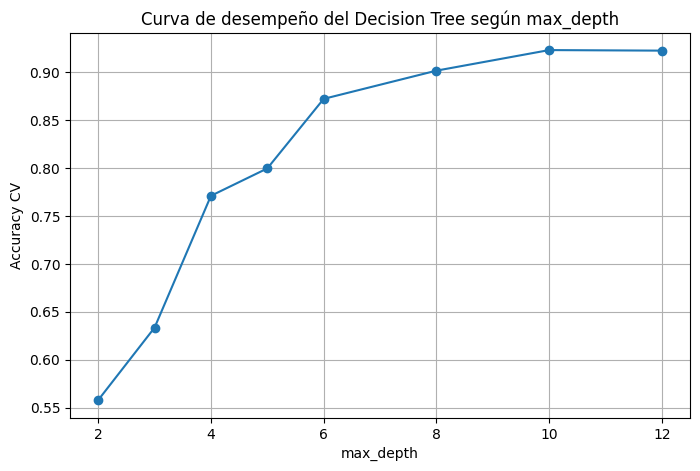

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(profundidades, resultados, marker='o')
plt.xlabel("max_depth")
plt.ylabel("Accuracy CV")
plt.title("Curva de desempeño del Decision Tree según max_depth")
plt.grid(True)
plt.show()


En este tipo de modelo no es eficiente aplicar este tipo de algoritmo, ya que encuentra con respecto a la exactitud del modelo, mas no si tiene sobreajuste, que en este caso, aplica entre mas profundo, mas sobreajuste.

#**Random Forest "Bosque aleatorio"**

In [ ]:
est2 = est2 = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=5)
est2.fit(X_train, y_train)

# Evaluar
rf_train_acc = accuracy_score(y_train, est2.predict(X_train))
rf_test_acc = accuracy_score(y_test, est2.predict(X_test))

print("Entrenamiento: ", rf_train_acc)
print("Test: ",rf_test_acc)
print("Reporte de metricas")
print(classification_report(y_test,est2.predict(X_test)))

s = cross_val_score(est2, X, y, cv=KFold(10, shuffle=True), scoring=make_scorer(accuracy_score))
print("accuracy %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))

r=classification_report(y_test,est2.predict(X_test),output_dict=True)
recall_rf=r['macro avg']['recall']


print("PREDICCIÓN")

print("Prediccion: ",est2.predict([X_test[10]]),"Real: ",y_test[10])
print("Prediccion: ",est2.predict([X_test[56]]),"Real: ",y_test[56])
print("Prediccion: ",est2.predict([X_test[1]]),"Real: ",y_test[1])
print("Prediccion: ",est2.predict([X_test[5]]),"Real: ",y_test[5])

Entrenamiento:  0.9069905213270142
Test:  0.8747044917257684
Reporte de metricas
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97        54
         1.0       0.76      0.86      0.81        58
         2.0       0.88      0.80      0.84        70
         3.0       0.92      1.00      0.96        60
         4.0       1.00      0.98      0.99        65
         5.0       0.85      0.76      0.80        58
         6.0       0.75      0.76      0.75        58

    accuracy                           0.87       423
   macro avg       0.88      0.88      0.87       423
weighted avg       0.88      0.87      0.87       423

accuracy 0.865 (+/- 0.01999)
PREDICCIÓN
Prediccion:  [5.] Real:  5.0
Prediccion:  [4.] Real:  4.0
Prediccion:  [6.] Real:  6.0
Prediccion:  [6.] Real:  6.0


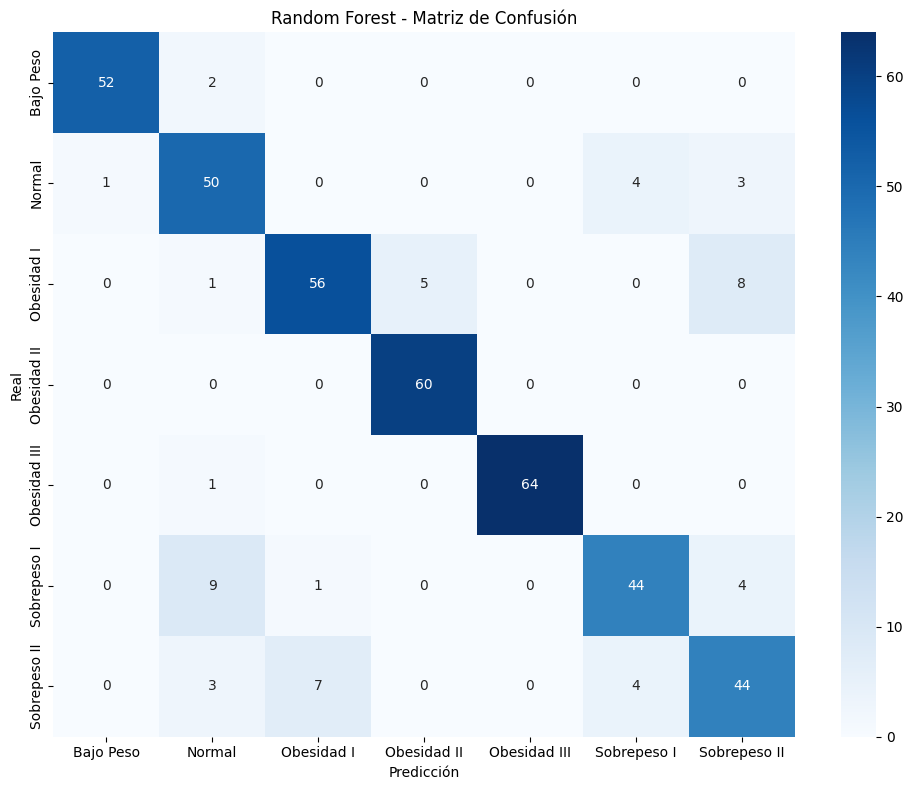

In [ ]:
abreviaturas = {
    0: 'Bajo Peso',
    1: 'Normal',
    2: 'Obesidad I',
    3: 'Obesidad II',
    4: 'Obesidad III',
    5: 'Sobrepeso I',
    6: 'Sobrepeso II'
}
labels_cortos = [abreviaturas.get(c, c) for c in est.classes_]

cm = confusion_matrix(y_test,est2.predict(X_test), labels=clases_originales)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_cortos,
            yticklabels=labels_cortos)
plt.title('Random Forest - Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

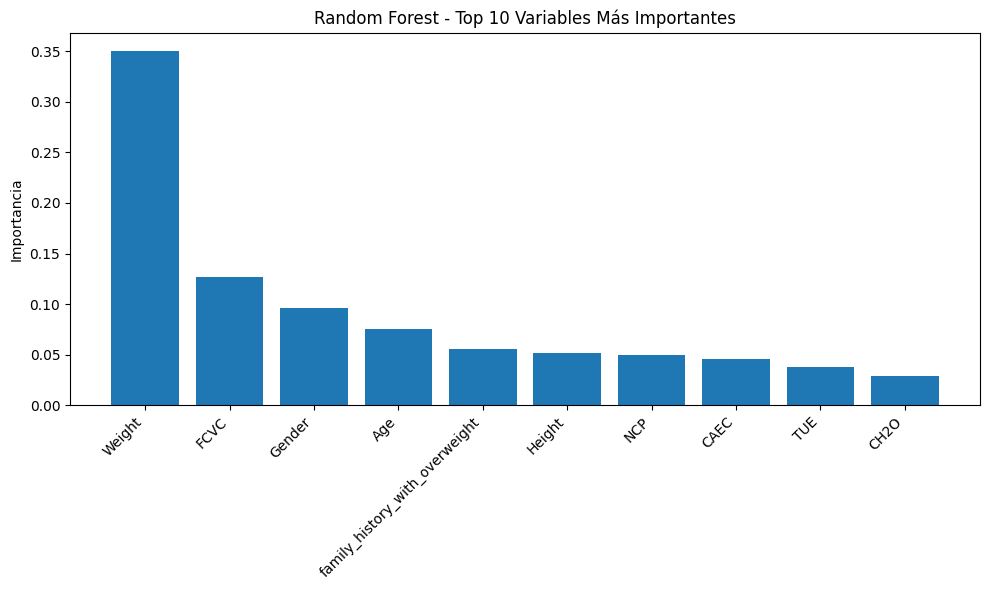

In [ ]:
importances = est2.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.bar(range(10), importances[indices])
plt.xticks(range(10), df.columns[:-1][indices], rotation=45, ha='right')
plt.title('Random Forest - Top 10 Variables Más Importantes')
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()

Formas de ver cual es el mejor n_estimators (numero de arboles)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

estimadores = [10, 15,30, 50, 80, 100,  200]
resultados = []

for n in estimadores:
    modelo = RandomForestClassifier(n_estimators=n, random_state=40)

    # Validación cruzada en training
    score = cross_val_score(modelo, X_train, y_train, cv=5, scoring='recall_macro').mean()
    resultados.append(score)
    print(f"{n} árboles → Accuracy CV: {score:.4f}")

# Mejor n_estimators
mejor_n = estimadores[np.argmax(resultados)]
print("\n Mejor n_estimators:", mejor_n)


10 árboles → Accuracy CV: 0.9118
15 árboles → Accuracy CV: 0.9239
30 árboles → Accuracy CV: 0.9340
50 árboles → Accuracy CV: 0.9407
80 árboles → Accuracy CV: 0.9425
100 árboles → Accuracy CV: 0.9413
200 árboles → Accuracy CV: 0.9465

 Mejor n_estimators: 200


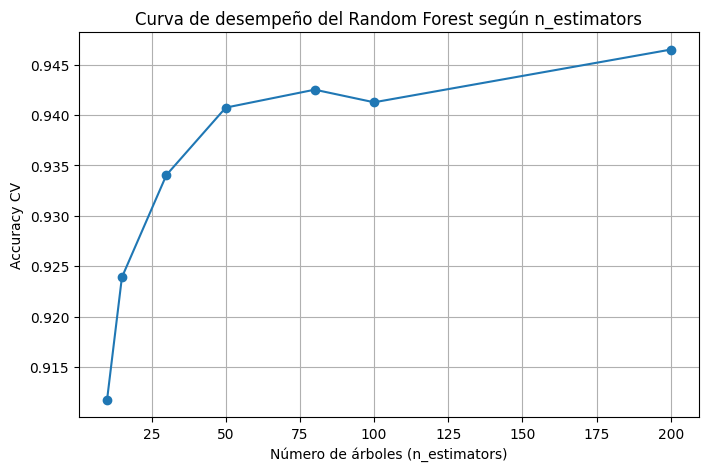

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(estimadores, resultados, marker='o')
plt.xlabel("Número de árboles (n_estimators)")
plt.ylabel("Accuracy CV")
plt.title("Curva de desempeño del Random Forest según n_estimators")
plt.grid(True)
plt.show()


En este tipo de modelo si es ideal aplicar este algoritmo, por que se analiza con cuantos arboles me da un mejor resultado, no hay sobre ajuste, ya que entre mayor sea el numero de arboles mas precision hay, pero es mas demorado y costoso.

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 7, 10],
    'min_samples_split': [2, 4],
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejor n_estimators:", grid.best_params_['n_estimators'])
print("Mejor combinación encontrada:", grid.best_params_)
print("Mejor accuracy:", grid.best_score_)


Mejor n_estimators: 200
Mejor combinación encontrada: {'max_depth': None, 'min_samples_split': 4, 'n_estimators': 200}
Mejor accuracy: 0.9496479553315892


Curva de aprendizaje

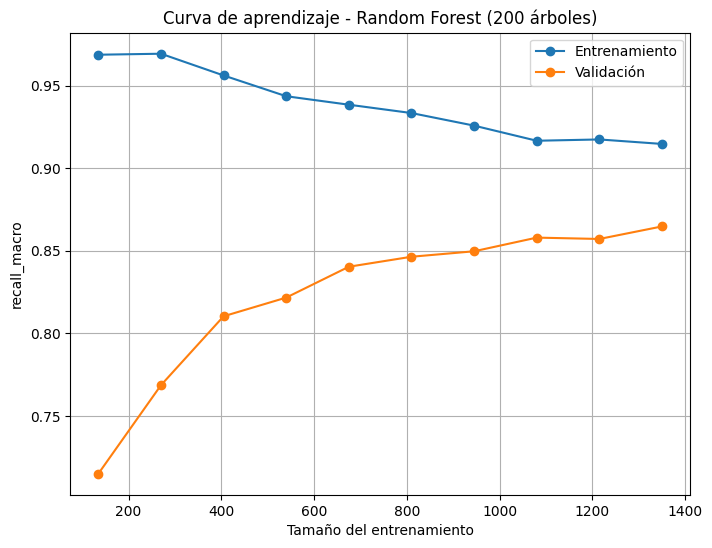

In [ ]:

train_sizes, train_scores, test_scores = learning_curve(
    est2,
    X_train,
    y_train,
    cv=5,
    scoring='recall_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=40
)

# Promedio de los resultados
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Gráfica
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, marker='o', label="Entrenamiento")
plt.plot(train_sizes, test_mean, marker='o', label="Validación")
#plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
#plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)
plt.title("Curva de aprendizaje - Random Forest (200 árboles)")
plt.xlabel("Tamaño del entrenamiento")
plt.ylabel("recall_macro")
plt.grid(True)
plt.legend()
plt.show()


#**SVM (Máquina de vectores de soporte)**

In [11]:


param_grid_svm = {
    'C': [0.1, 1, 10, 50, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

svm = SVC()

grid_svm = GridSearchCV(
    svm,
    param_grid_svm,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print(" Mejor combinación encontrada:", grid_svm.best_params_)
print(" Mejor accuracy en validación:", grid_svm.best_score_)



 Mejor combinación encontrada: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
 Mejor accuracy en validación: 0.9571363709364036


In [12]:
est3= SVC(C=100,gamma="scale",kernel="linear")
est3.fit(X_train, y_train)

train_acc = accuracy_score(y_train, est3.predict(X_train))
test_acc = accuracy_score(y_test, est3.predict(X_test))

print("Accuracy Entrenamiento:", train_acc)
print("Accuracy Test:", test_acc)
print("Reporte de metricas")
print(classification_report(y_test,est3.predict(X_test)))

r=classification_report(y_test,est3.predict(X_test),output_dict=True)
recall_svm=r['macro avg']['recall']


print("PREDICCIÓN")

print("Prediccion: ",est3.predict([X_test[10]]),"Real: ",y_test[10])

print("Prediccion: ",est3.predict([X_test[56]]),"Real: ",y_test[56])

print("Prediccion: ",est3.predict([X_test[1]]),"Real: ",y_test[1])
print("Prediccion: ",est3.predict([X_test[12]]),"Real: ",y_test[12])
print("Prediccion: ",est3.predict([X_test[0]]),"Real: ",y_test[0])

Accuracy Entrenamiento: 0.9727488151658767
Accuracy Test: 0.966903073286052
Reporte de metricas
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97        54
         1.0       0.96      0.93      0.95        58
         2.0       0.97      0.99      0.98        70
         3.0       0.97      1.00      0.98        60
         4.0       1.00      0.97      0.98        65
         5.0       0.92      0.95      0.93        58
         6.0       0.98      0.95      0.96        58

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423

PREDICCIÓN
Prediccion:  [5.] Real:  5.0
Prediccion:  [4.] Real:  4.0
Prediccion:  [6.] Real:  6.0
Prediccion:  [2.] Real:  2.0
Prediccion:  [1.] Real:  1.0


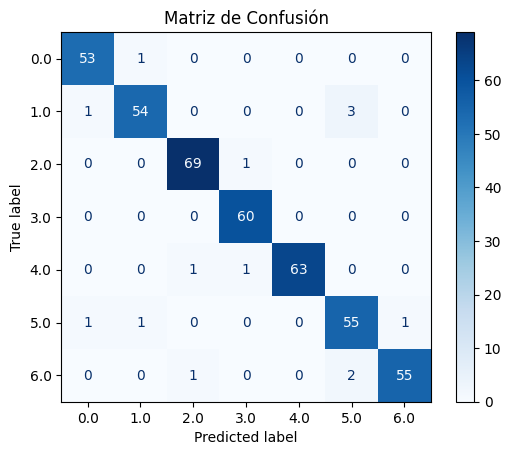

In [13]:
cm = confusion_matrix(y_test, est3.predict(X_test), labels=est3.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=est3.classes_)
disp.plot(cmap=plt.cm.Blues)  # Puedes cambiar el colormap
plt.title("Matriz de Confusión")
plt.show()

Curva de aprendizaje

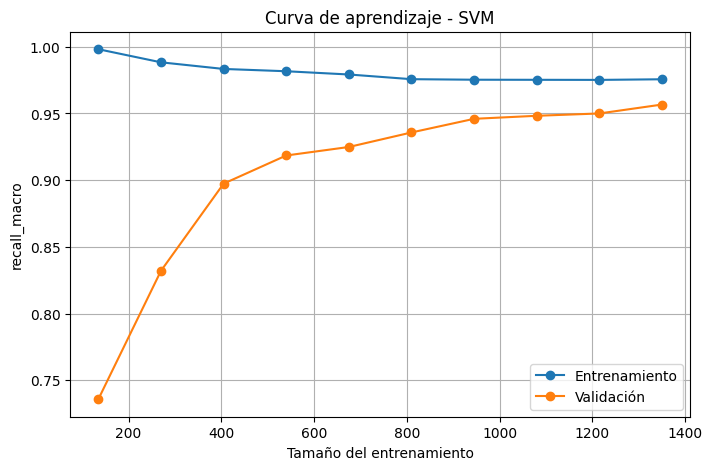

In [14]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    est3,
    X_train,
    y_train,
    cv=5,
    scoring='recall_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=40
)

train_mean = train_scores.mean(axis=1)
test_mean  = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label="Entrenamiento")
plt.plot(train_sizes, test_mean, marker='o', label="Validación")
#plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
#plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)

plt.title("Curva de aprendizaje - SVM")
plt.xlabel("Tamaño del entrenamiento")
plt.ylabel("recall_macro")
plt.grid(True)
plt.legend()
plt.show()


#CONCLUSION

En nuestro enfoque de identificar el nivel de obesidad para ajsutar mi rutina (consumo de alimentos, ejercicio y sedentarismo), nos centramos en la metrica de Recall, la cual me permite castigar al modelo segun los falsos negativos que me proporciona, ya que mi objetivo es identificar los de mayor nivel de obesidad, es decir, no importa si clasifica mal un Falso positivo, pero si afecta el falso negativo, ya que pueden sufrir una enfermedad mas grave ligada a esta.

Fuente:
[Beneficio del modelo](https://www.datacamp.com/es/blog/machine-learning-models-explained)